### Modelo supervisionado de regressão

Este notebook treina um modelo que prevê a taxa de alfabetização (`pc_indicador_alfabetizacao`) no recorte município/rede/ano, usando o `features.csv` gerado na engenharia de atributos.

O fluxo cobre:

1. Separação de alvo e features, sem leakage
2. Holdout temporal (treino em 2023, teste em 2024)
3. Pipeline sklearn (imputação + scaler + regressor)
4. Baseline (`Ridge`) versus modelo principal (`HistGradientBoostingRegressor`)
5. Métricas, gráficos, SHAP e exemplo de uso (`predict` + ranking de risco)

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.evaluation.explain import mean_abs_shap, plot_shap_summary, shap_values
from src.evaluation.metrics import regression_metrics
from src.evaluation.plots import plot_pred_vs_actual, plot_residuals
from src.evaluation.ranking import rank_risk
from src.modeling.persist import load_pipeline, save_pipeline
from src.modeling.train import persist_reports, train_and_evaluate
from src.preprocessing.features import (
    DEFAULT_META,
    DROP_ALWAYS,
    TARGET,
    YEAR_COL,
    feature_columns,
    load_features,
    temporal_holdout,
)

### Alvo e exclusões

O alvo é a taxa contínua de alfabetização. Também saem constante (`nu_serie`), `pct_rural` (espelho de urbana) e `qtd_fam_ate_meio_sm` (soma de pobreza + baixa renda).

No holdout temporal, `ano_2024` também sai de X.

In [2]:
df = load_features()
print(df.shape)
print("alvo:", TARGET)
print("excluídas:", DROP_ALWAYS)
print("features de treino:", feature_columns(df, drop_year=True))

(12417, 22)
alvo: pc_indicador_alfabetizacao
excluídas: ['pc_indicador_alfabetizacao', 'nu_serie', 'pct_rural', 'qtd_fam_ate_meio_sm']
features de treino: ['vl_proficiencia_media', 'vl_proficiencia_mediana', 'qt_alunos_avaliados', 'qtd_fam_pobreza', 'qtd_fam_baixa_renda', 'qtd_fam_renda_zero', 'taxa_atualizacao_geral_pct', 'taxa_atualizacao_ate_meio_sm_pct', 'qtd_escolas', 'pct_urbana', 'ds_rede_municipal', 'ds_rede_privada', 'nome_regiao_nordeste', 'nome_regiao_norte', 'nome_regiao_sudeste', 'nome_regiao_sul', 'uf_freq']


### Split temporal

Treino: `ano_2024 == 0`. Teste: `ano_2024 == 1`. A validação cruzada (5 folds) acontece só no treino, dentro do `Pipeline`, para o scaler não ver o holdout.

In [3]:
X_train, y_train, X_test, y_test = temporal_holdout(df)
print(f"treino: {len(X_train)} | teste: {len(X_test)}")
print("ano nas features?", YEAR_COL in X_train.columns)
X_train.head()

treino: 5881 | teste: 6536
ano nas features? False


,vl_proficiencia_media,vl_proficiencia_mediana,qt_alunos_avaliados,qtd_fam_pobreza,qtd_fam_baixa_renda,qtd_fam_renda_zero,taxa_atualizacao_geral_pct,taxa_atualizacao_ate_meio_sm_pct,qtd_escolas,pct_urbana,ds_rede_municipal,ds_rede_privada,nome_regiao_nordeste,nome_regiao_norte,nome_regiao_sudeste,nome_regiao_sul,uf_freq
0,737.60,734.01,49,1032,307,560,0.7553,0.8017,11,0.7273,1,0,0,0,1,0,0.175485
1,747.21,751.72,376,1343,987,487,0.7099,0.8045,35,0.7714,1,0,0,0,1,0,0.175485
2,791.68,795.49,85,288,211,151,0.5359,0.7748,5,1.0000,1,0,0,0,1,0,0.175485
3,736.56,737.62,268,3194,1618,2053,0.7108,0.8459,38,0.9737,1,0,0,0,1,0,0.175485
4,730.09,728.07,277,4477,924,93,0.8051,0.9036,81,0.3457,1,0,0,0,1,0,0.175485


### Treino e validação

`train_and_evaluate` ajusta o baseline linear e o HistGradientBoosting, reporta CV no treino e métricas no holdout de 2024. O pipeline persistido é o HGB.

In [4]:
ridge, hgb, summary = train_and_evaluate(df)
persist_reports(summary)
model_path = save_pipeline(hgb)
pd.DataFrame(
    {
        "ridge_cv": summary["ridge"]["cv"],
        "ridge_test": summary["ridge"]["test"],
        "hgb_cv": summary["hist_gradient_boosting"]["cv"],
        "hgb_test": summary["hist_gradient_boosting"]["test"],
    }
).T

,cv_rmse,cv_mae,cv_r2,rmse,mae,r2
ridge_cv,0.061915,0.045606,0.907316,NaN,NaN,NaN
ridge_test,NaN,NaN,NaN,0.076366,0.059401,0.843611
hgb_cv,0.042522,0.030128,0.956274,NaN,NaN,NaN
hgb_test,NaN,NaN,NaN,0.053198,0.039069,0.924109


### Diagnóstico no holdout

MAE é o erro médio em pontos da taxa (0,08 = 8 pontos percentuais). Os gráficos abaixo comparam previsto vs real e a distribuição dos resíduos.

{'rmse': 0.05319805558813706, 'mae': 0.03906872366320415, 'r2': 0.9241086828904325}


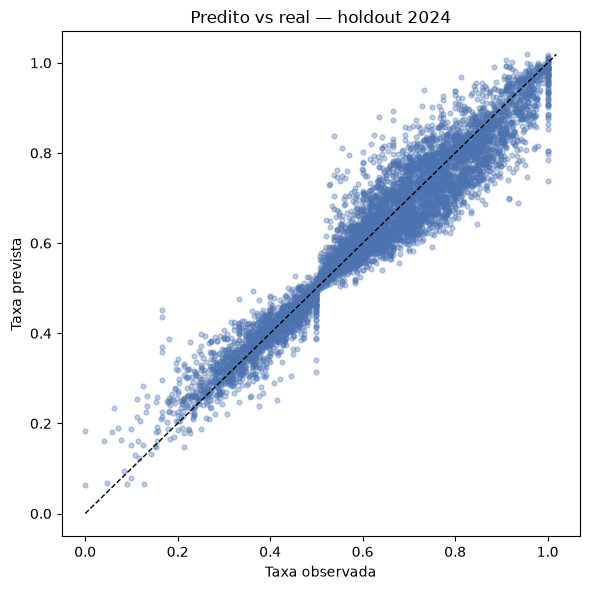

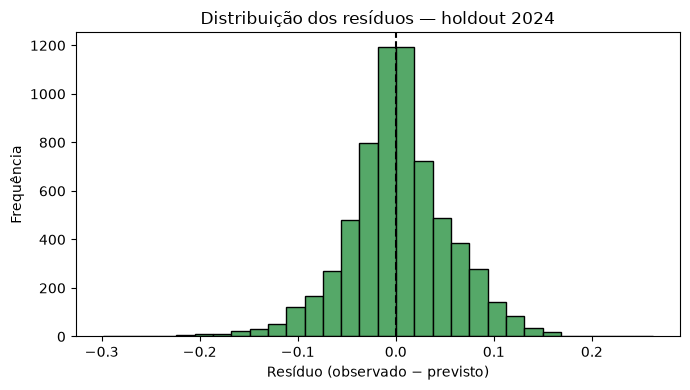

modelo salvo em C:\Users\Victor\OneDrive\Documentos\FIAP - AI Scientist\Fase 3 - Modeling Machine Learning\Tech_Challenge_Fase_3\models\regressor_alfabetizacao.joblib


In [5]:
y_pred = hgb.predict(X_test)
print(regression_metrics(y_test, y_pred))

images = ROOT / "images"
fig1 = plot_pred_vs_actual(y_test, y_pred, images / "pred_vs_real.png")
fig2 = plot_residuals(y_test, y_pred, images / "residuos.png")
plt.show()
print("modelo salvo em", model_path)

### Interpretabilidade (SHAP)

Valores SHAP no regressor já ajustado, com as features transformadas pelo pipeline. Isso responde quais fatores mais empurram a taxa prevista para cima ou para baixo.

c:\Users\Victor\AppData\Local\pypoetry\Cache\virtualenvs\tech-challenge-fase-3-17I3P-Hc-py3.13\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


vl_proficiencia_mediana       0.118082
vl_proficiencia_media         0.058939
nome_regiao_sul               0.010600
uf_freq                       0.009060
qt_alunos_avaliados           0.004801
taxa_atualizacao_geral_pct    0.001992
qtd_fam_pobreza               0.001944
pct_urbana                    0.001838
qtd_fam_renda_zero            0.001806
nome_regiao_nordeste          0.001615
dtype: float64


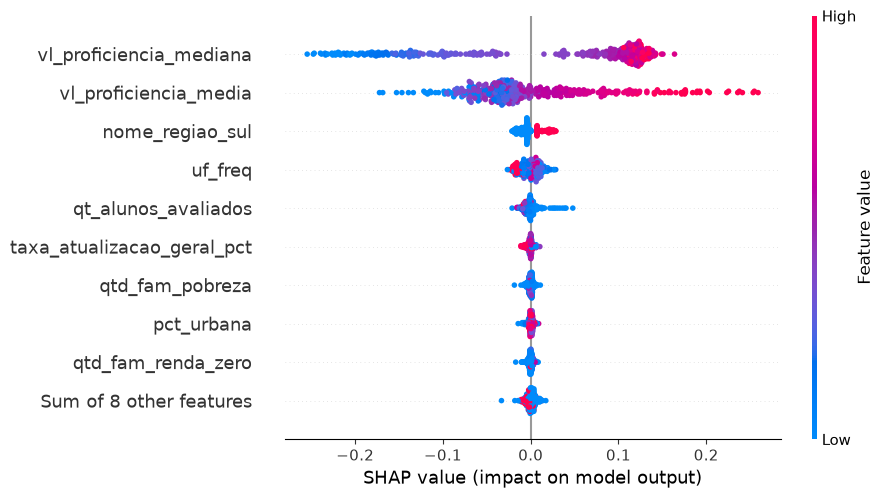

In [6]:
explanation = shap_values(hgb, X_test)
print(mean_abs_shap(explanation).head(10))
fig_shap = plot_shap_summary(explanation, images / "shap_summary.png")
plt.show()

### Como usar o pipeline salvo

Carregue o arquivo `.joblib` e chame `predict` com as **mesmas colunas** do treino. O risco usa a meta de referência 0,60 (limiar de política). `features.csv` não tem `id_municipio`; o ranking é por recorte. Metas oficiais estão em `data/wide_analitica_alfabetizacao.csv` e não entram como feature.

In [7]:
modelo = load_pipeline()
taxa_nova = modelo.predict(X_test.head(5))
print("exemplo predict:", taxa_nova)

ranking = rank_risk(X_test, y_pred, y_true=y_test, meta=DEFAULT_META, top_n=10)
ranking[["taxa_prevista", "taxa_observada", "meta_referencia", "risco"]].head(10)

exemplo predict: [0.15288302 0.82934527 0.65078583 0.57194645 0.26415181]


,taxa_prevista,taxa_observada,meta_referencia,risco
6405,0.063160,0.0000,0.6,0.536840
10258,0.064717,0.1273,0.6,0.535283
7245,0.064990,0.0909,0.6,0.535010
6007,0.068034,0.0476,0.6,0.531966
7829,0.079171,0.1000,0.6,0.520829
12082,0.094093,0.0833,0.6,0.505907
8548,0.122222,0.1154,0.6,0.477778
7638,0.129088,0.1081,0.6,0.470912
6355,0.131595,0.1429,0.6,0.468405
7525,0.146533,0.2143,0.6,0.453467
